In [2]:
import requests, json, time, tqdm
import pandas as pd
import matplotlib as mb
import numpy as np

def get_data(ticker, period = "h6"):
    url = f"https://tornsy.com/api/{ticker}?interval={period}"
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"Failed to fetch data for {ticker}. Status code: {response.status_code}")
    data = response.json()
    # print(data)
    df = pd.DataFrame(data["data"], columns=["Timestamp", "Opening Price", "Closing Price", "High Price", "Low Price", "No of Shares"])
    df = df.sort_values(by="Timestamp", ascending=True)
    return df

In [3]:
def normalize(series, max, min):
    series = series.astype(float)
    norm_series = (series - min) / (max - min)
    return norm_series




In [7]:
import matplotlib.pyplot as plt
def plot(series_list):
    # plot all series in the same figure
    plt.figure(figsize=(10, 5))
    for series in series_list:
        plt.plot(series, label=series.name)
    plt.xlabel('Time') 
    plt.ylabel('Normalized Value')
    plt.title('Normalized Stock Prices')
    plt.legend()
    plt.grid()
    plt.show()
    
    

In [8]:
def get_normalized_data(tickers):
    series_list = []
    for ticker in tqdm.tqdm(tickers):
        data = get_data(ticker)
        price = data["Low Price"].astype(float)
        # print(price)
        max_price = price.max()
        min_price = price.min()
        normalized_data = normalize(price, max_price, min_price)
        series_list.append(normalized_data)
        time.sleep(1)
    return series_list



100%|██████████| 2/2 [00:02<00:00,  1.47s/it]


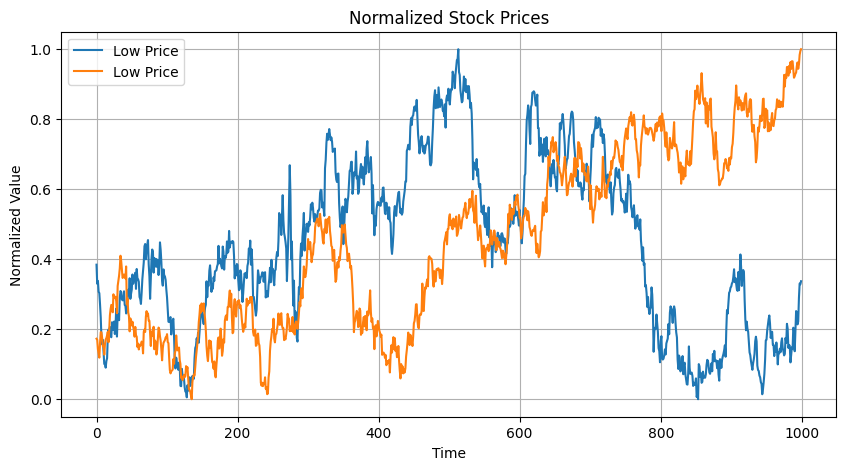

In [9]:
plot(get_normalized_data(["LAG", "ASS"]))

In [11]:
stockNames = [
    "TSB",
    "TCI",
    "SYS",
    "LAG",
    "IOU",
    "GRN",
    "THS",
    "YAZ",
    "TCT",
    "CNC",
    "MSG",
    "TMI",
    "TCP",
    "IIL",
    "FHG",
    "SYM",
    "LSC",
    "PRN",
    "EWM",
    "TCM",
    "ELT",
    "HRG",
    "TGP",
    "MUN",
    "WSU",
    "IST",
    "BAG",
    "EVL",
    "MCS",
    "WLT",
    "TCC",
    "ASS",
    "CBD",
    "LOS",
    "PTS"
]


all_data = get_normalized_data(stockNames)

100%|██████████| 35/35 [00:51<00:00,  1.47s/it]


100%|██████████| 8/8 [00:11<00:00,  1.47s/it]


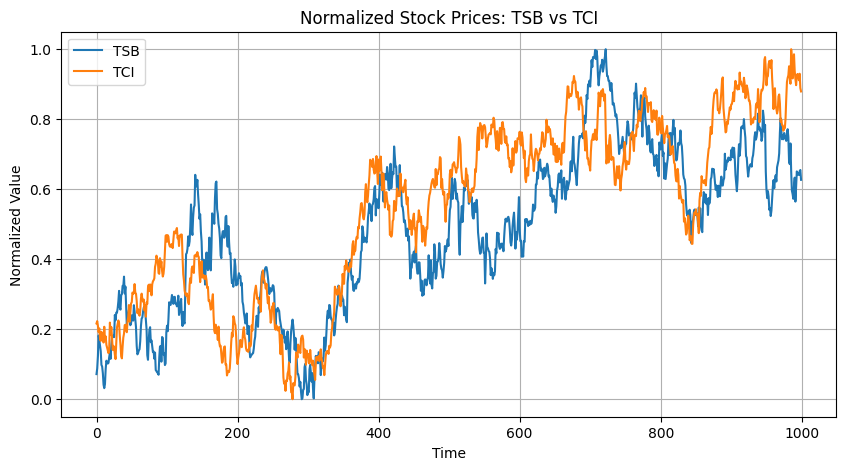

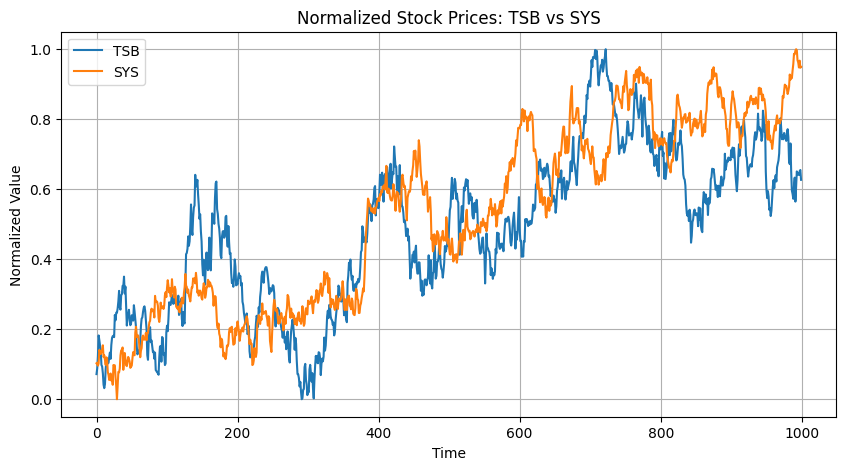

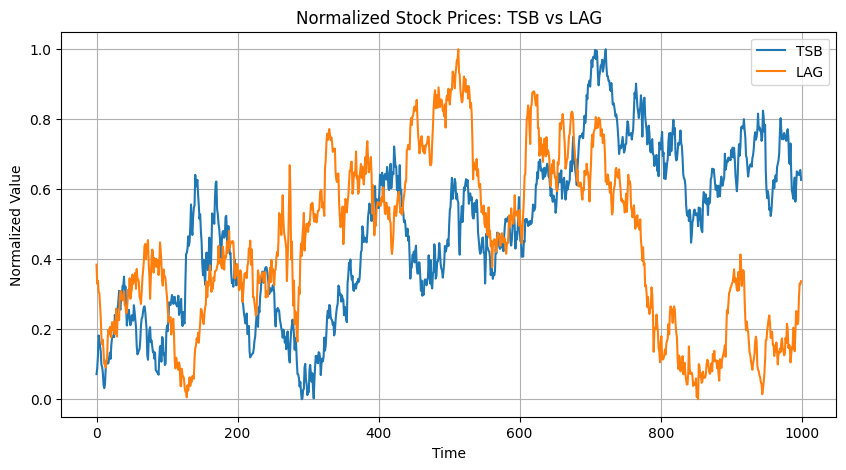

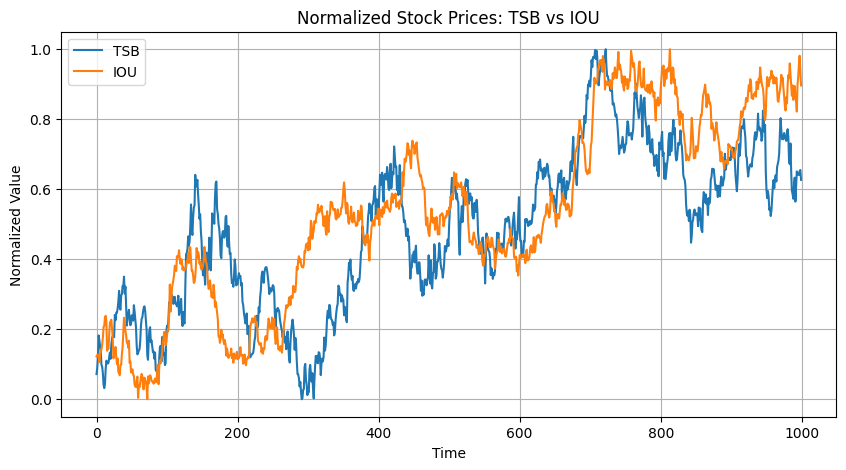

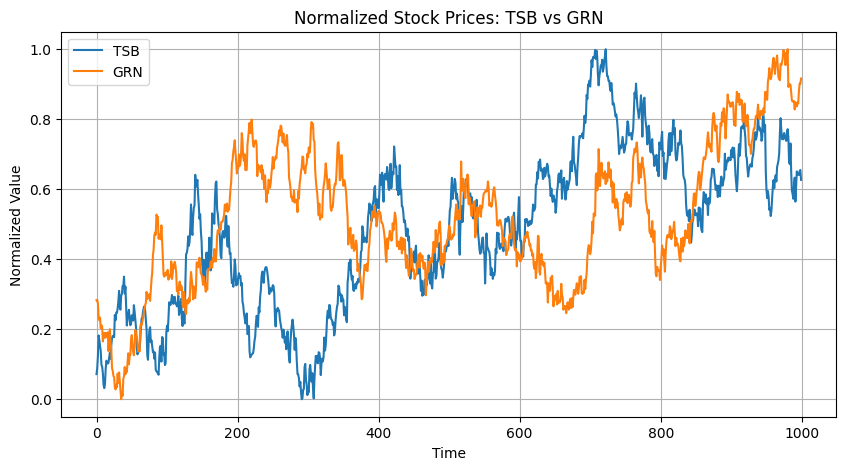

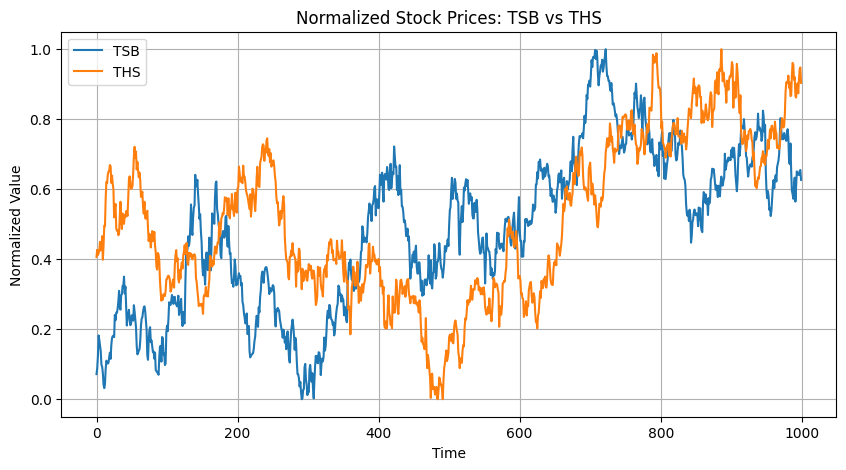

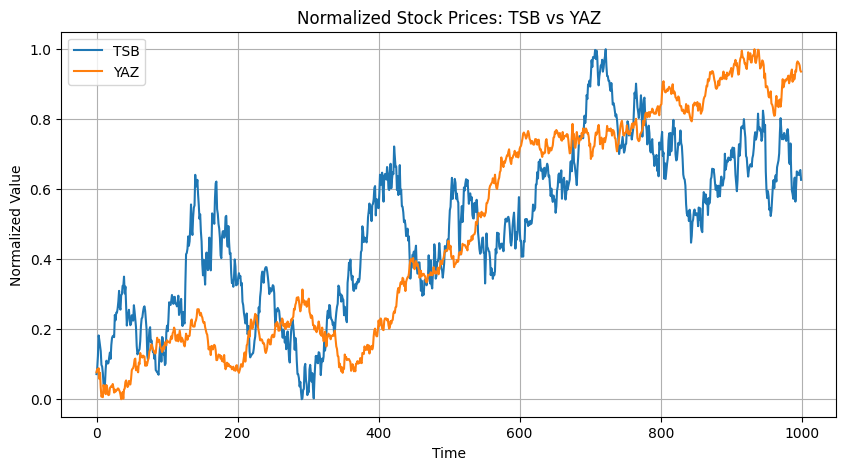

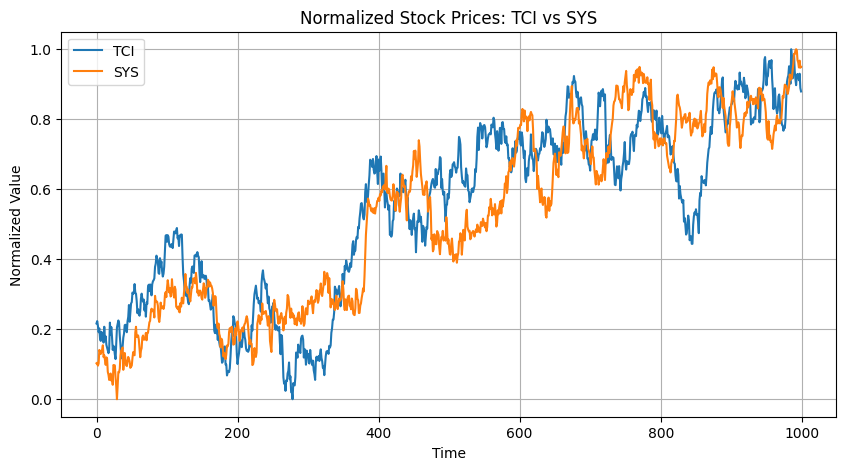

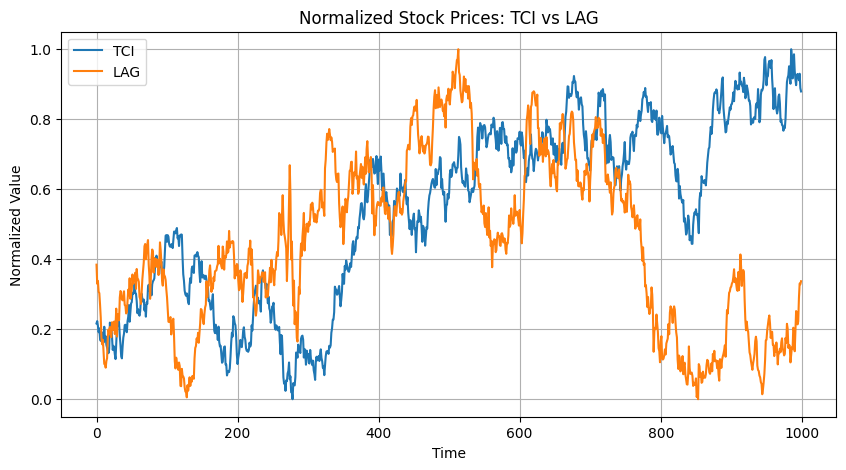

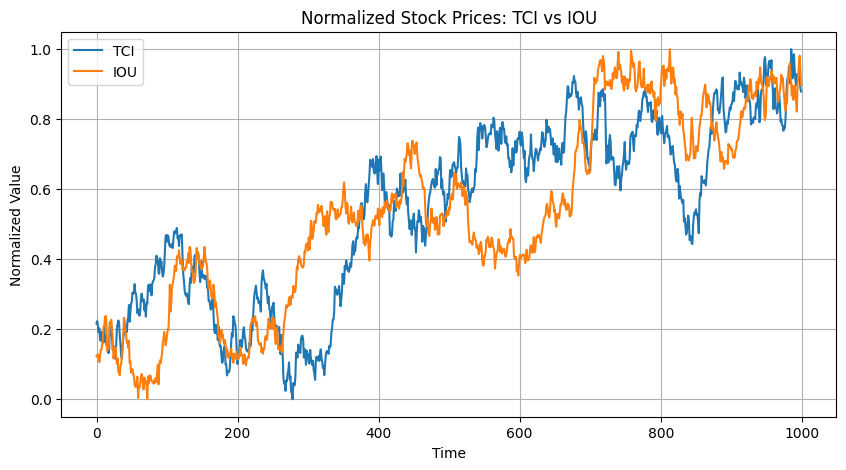

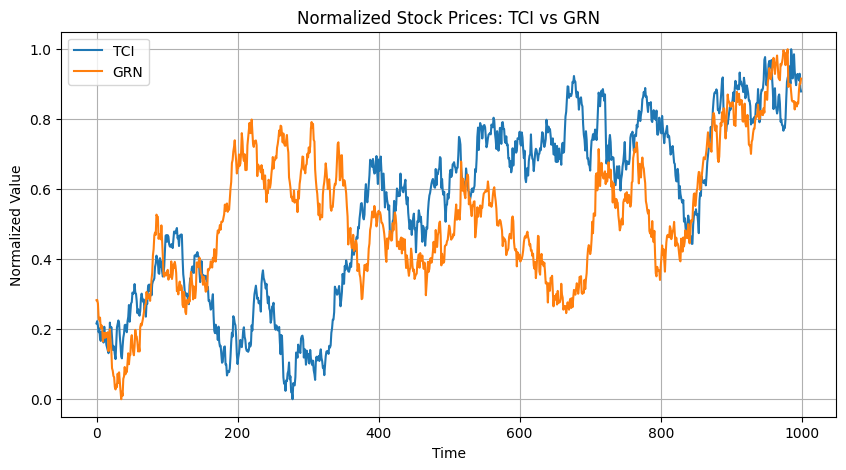

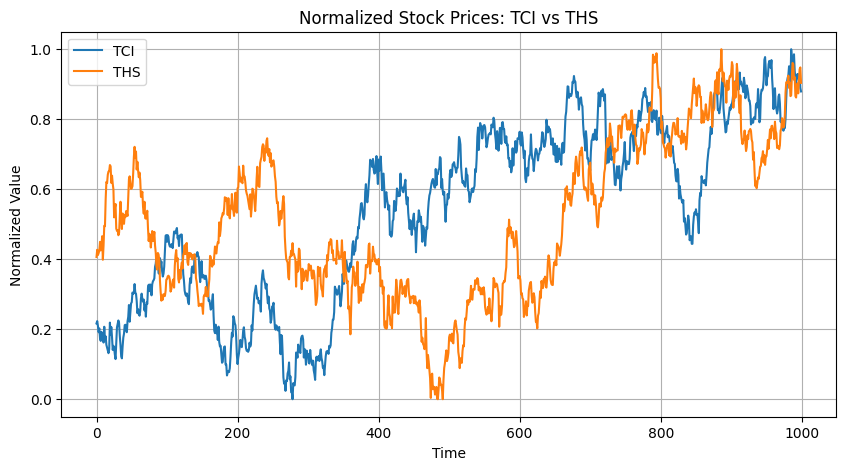

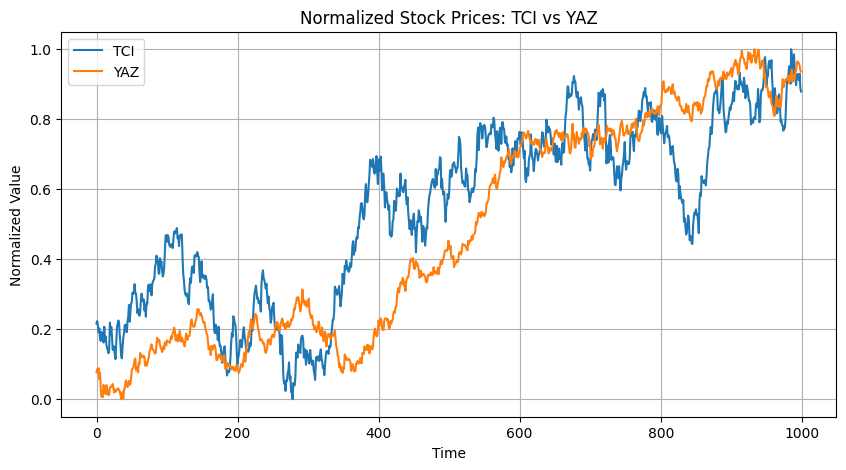

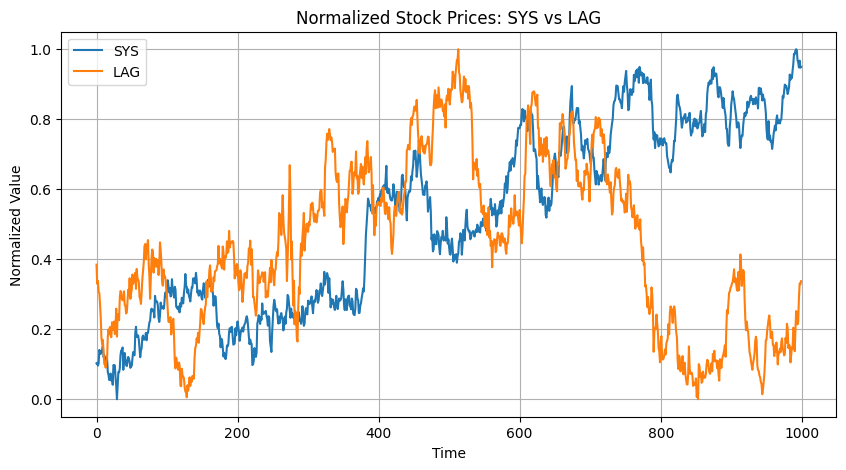

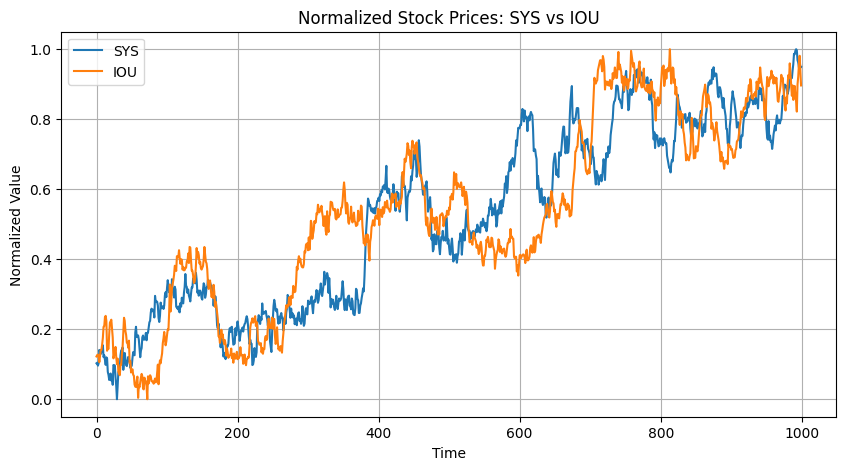

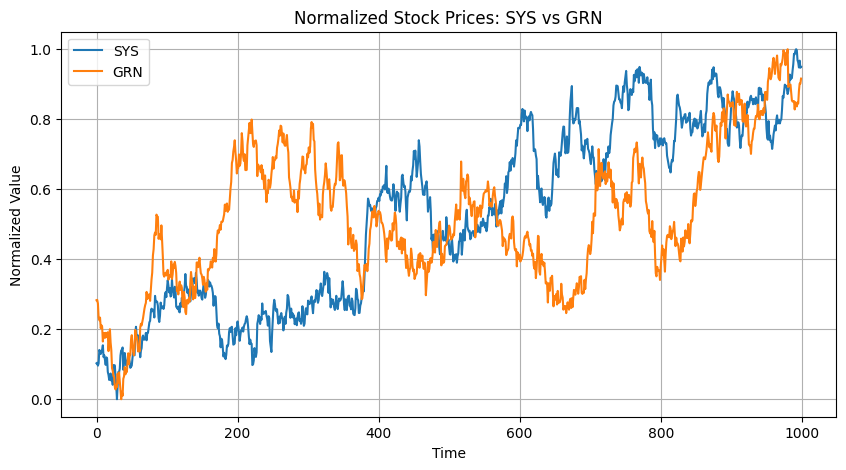

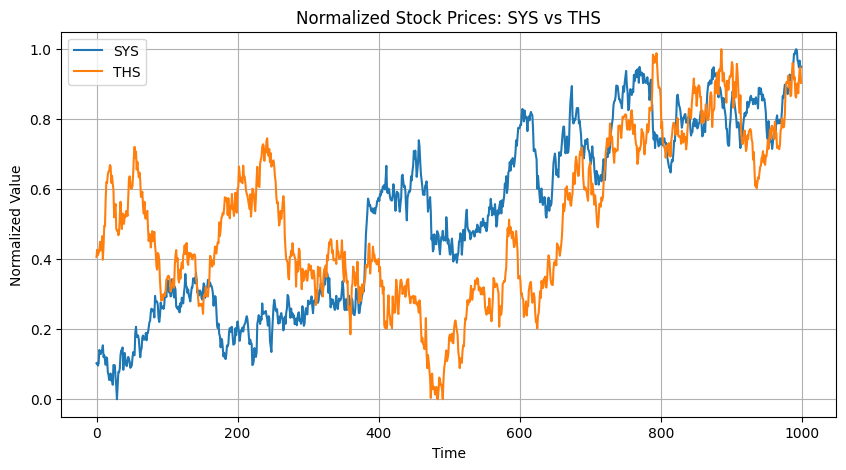

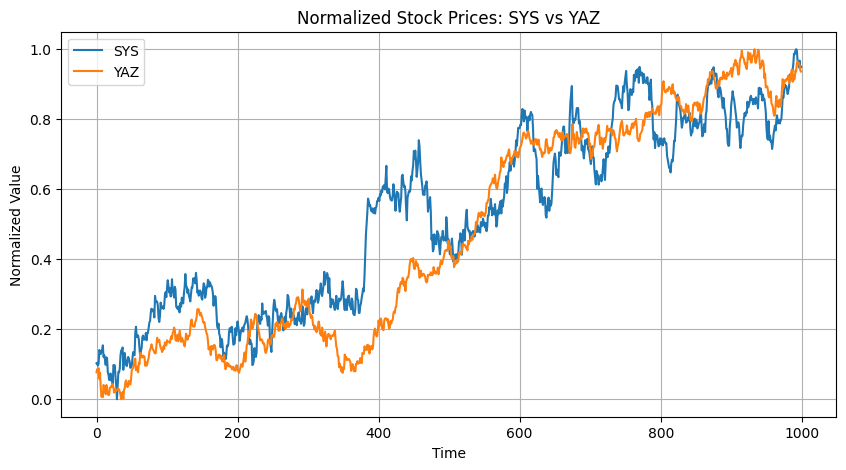

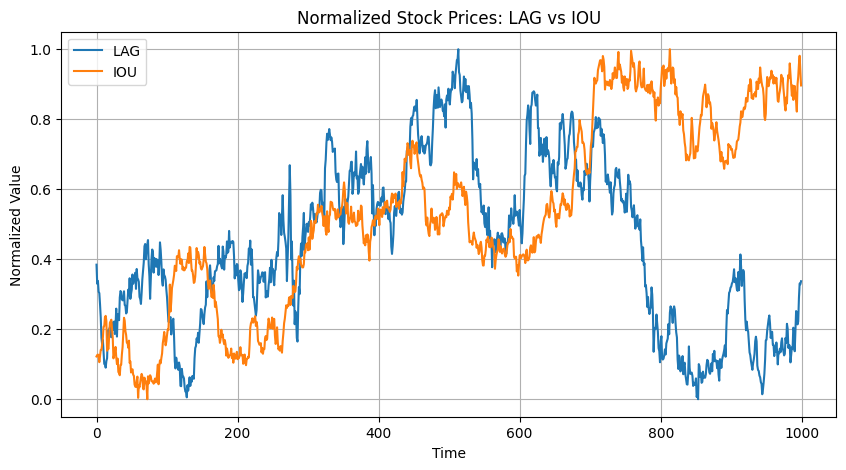

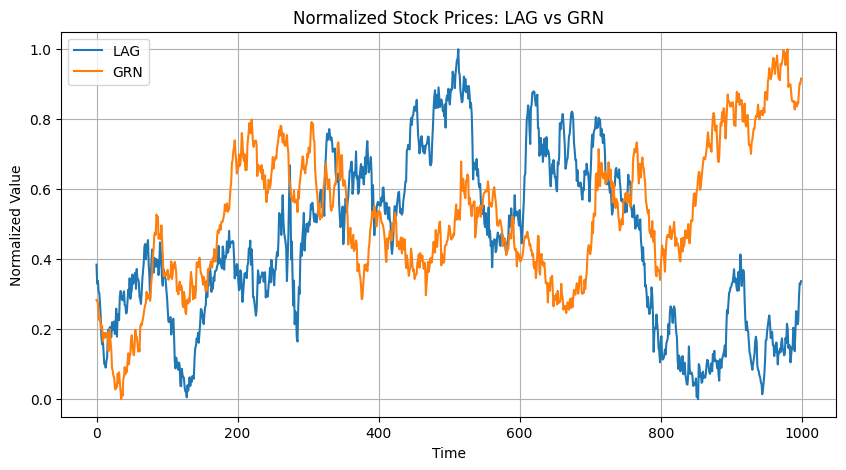

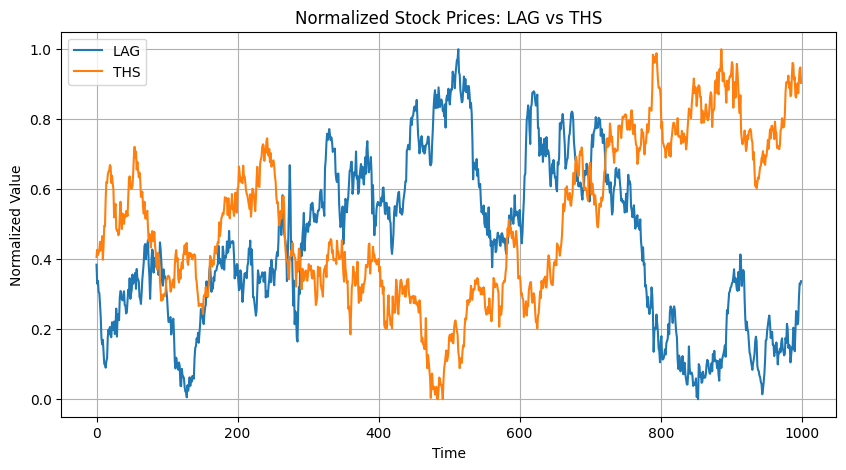

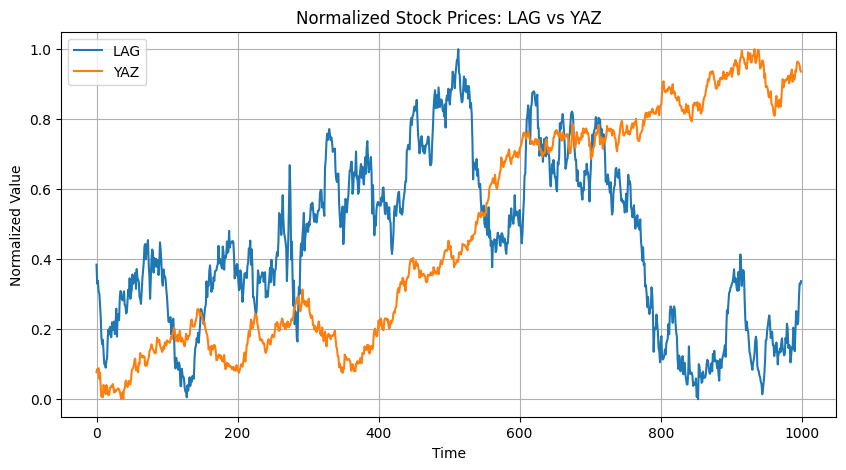

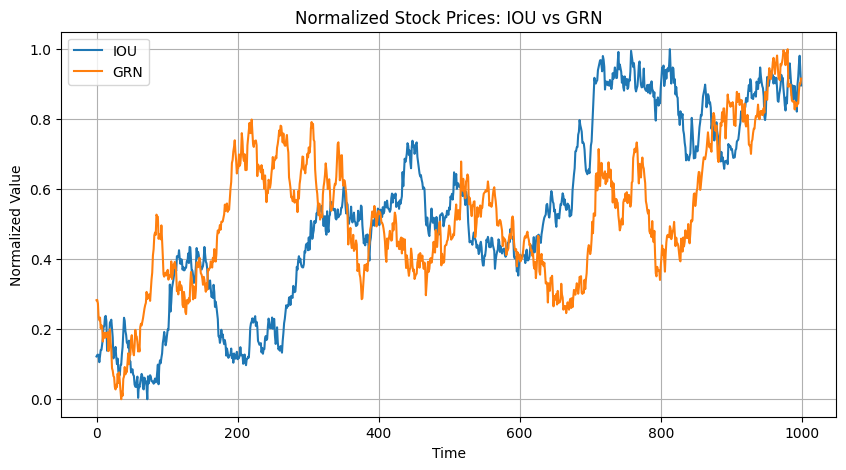

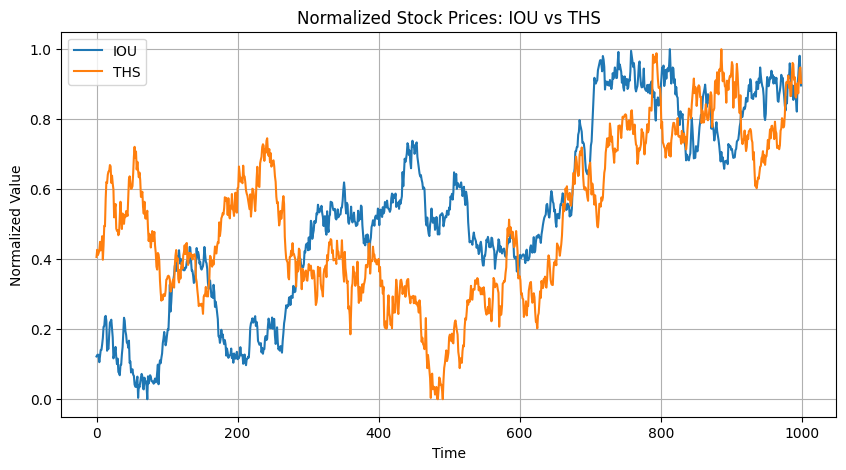

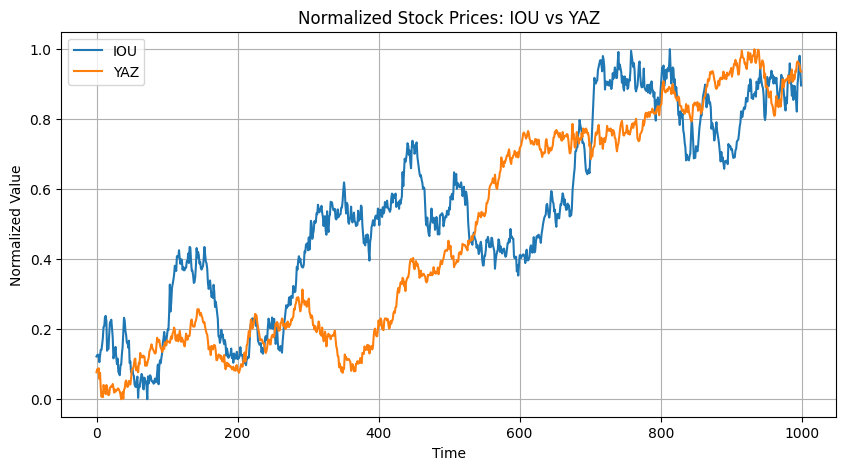

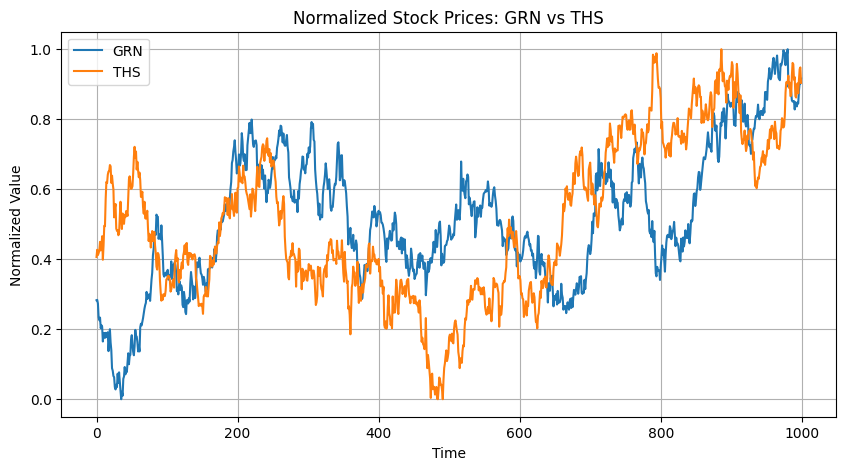

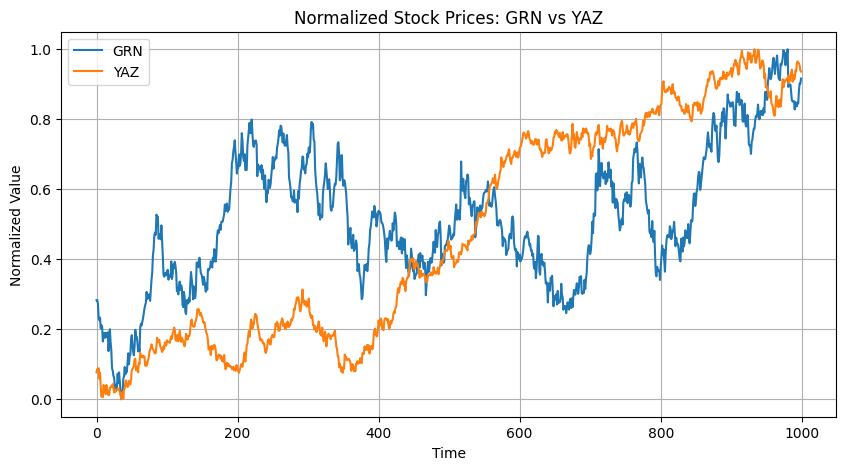

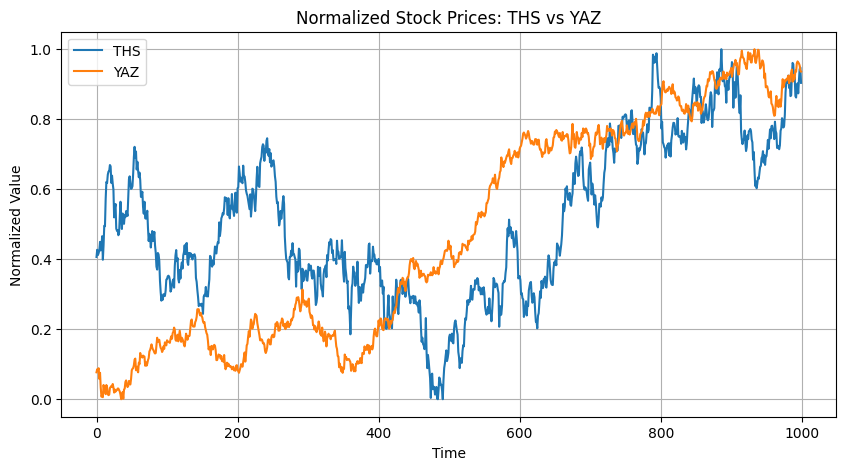

In [10]:

def plot_all_combinations():
    series_list = all_data
    for i in range(len(series_list)):
        for j in range(i + 1, len(series_list)):
            plt.figure(figsize=(10, 5))
            plt.plot(series_list[i], label=stockNames[i])
            plt.plot(series_list[j], label=stockNames[j])
            plt.xlabel('Time') 
            plt.ylabel('Normalized Value')
            plt.title(f'Normalized Stock Prices: {stockNames[i]} vs {stockNames[j]}')
            plt.legend()
            plt.grid()
            plt.show()

plot_all_combinations()


# plot_all_stocks()